<a href="https://colab.research.google.com/github/ArlethSosa/Space-Y/blob/main/SPACE_Y_Parte_4_Visualizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Space Y**
## Parte 4. Visualizacón de analisis exploratorio de datos y preparación de datos

In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

url="/content/drive/MyDrive/dataset_part_2.csv"
df=pd.read_csv(url)

Mounted at /content/drive


In [4]:
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,without landing pad,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,without landing pad,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,without landing pad,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,without landing pad,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,without landing pad,1.0,0,B1004,-80.577366,28.561857,0



**Grafica 1. relación entre numero de vuelos y masa de carga util.**


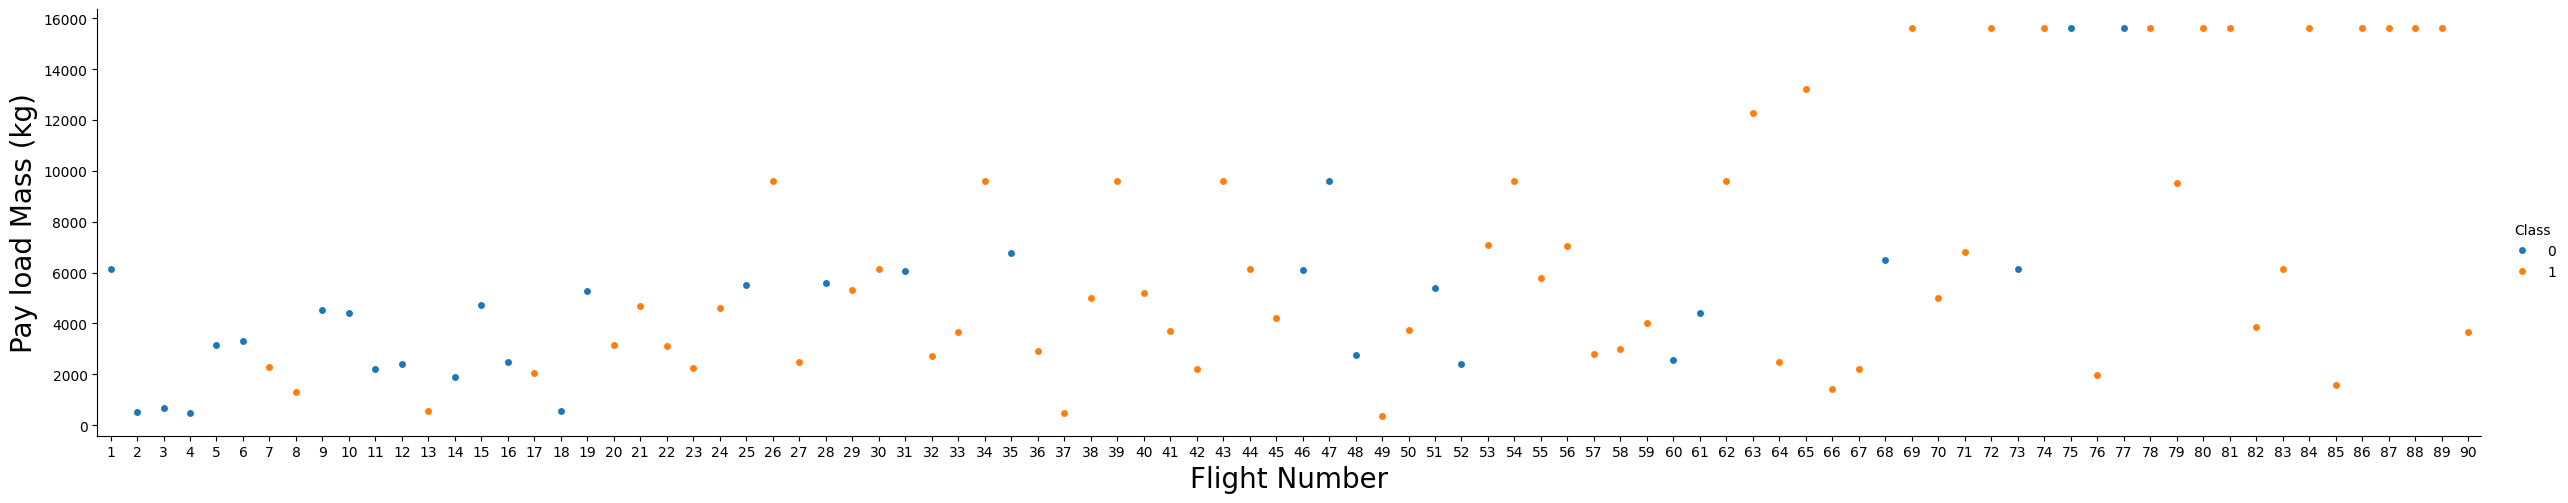

In [5]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

En esta grafica se puede ver como en los ultimos lanzamientos se han obtenido aterrizajes exitosos tanto con cargas pequeñas y grandes.
Por otra parte se puede ver como al avance del numero de vuelo, la masa que sortan los cohetes que aterrizan con exito es mayor.

**Grafica 2. Visualización de la relación entre el número de vuelo y el sitio de lanzamiento.**

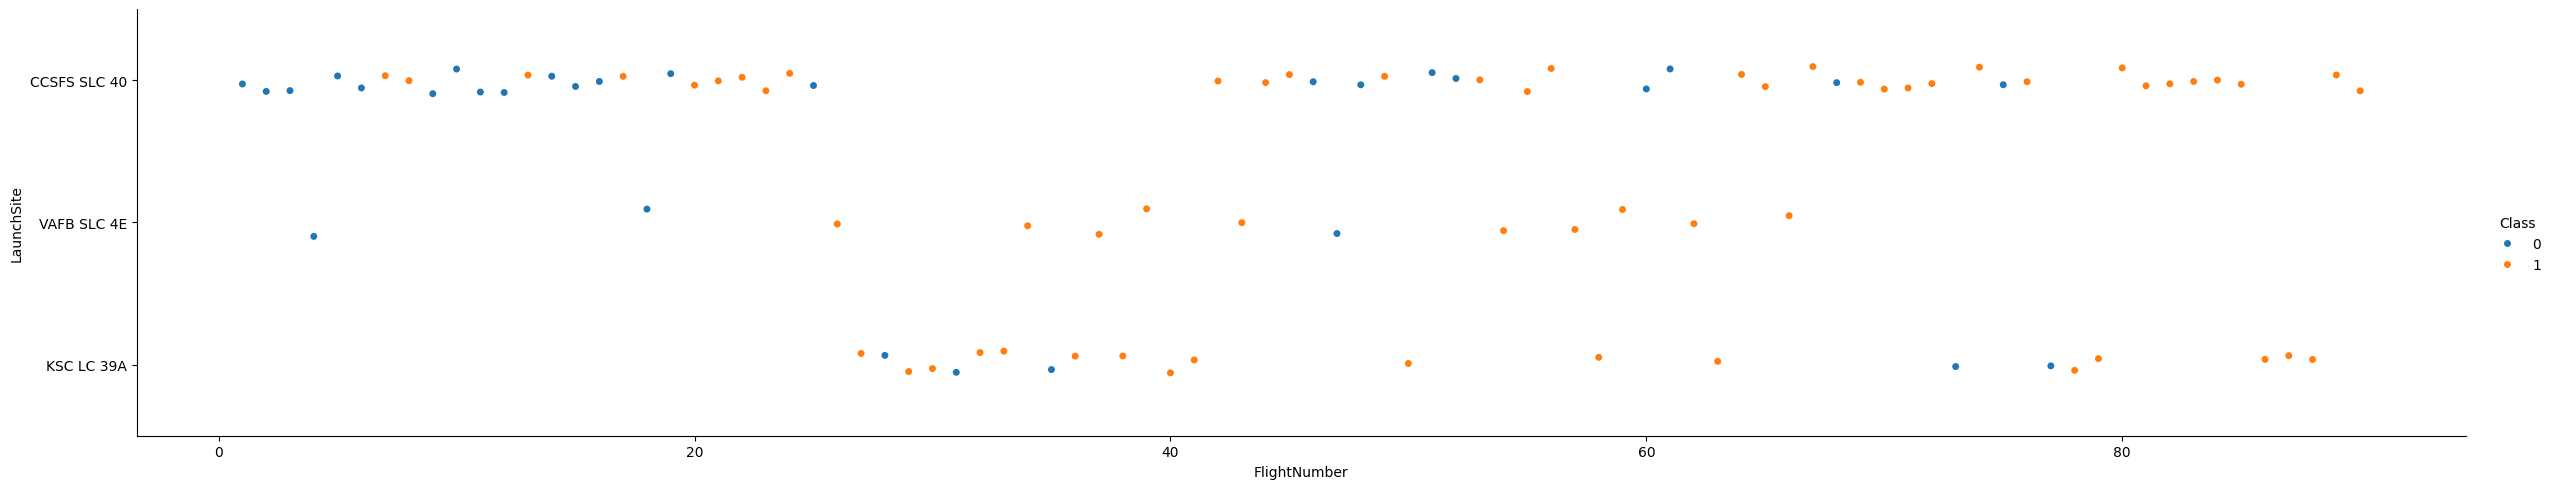

In [6]:
sns.catplot(x="FlightNumber", y="LaunchSite", data=df, hue='Class', aspect = 5)
plt.xlabel("FlightNumber")
plt.ylabel("LaunchSite")
plt.show()

Esa visualización sirve para entender cómo se distribuyen los lanzamientos y su evolución según el sitio de lanzamiento.
Se puede observar como en los utlimos intentos de lanzamiento los 3 sitios han obtenido aterrizajes exitosos, además de indentificar que el sitio CCSFS SLC 40 es el que ha realizado mas lanzamientos de los 3.

**Gráfica 3.Visualización de  la relación entre la masa de la carga útil y el sitio de lanzamiento.**


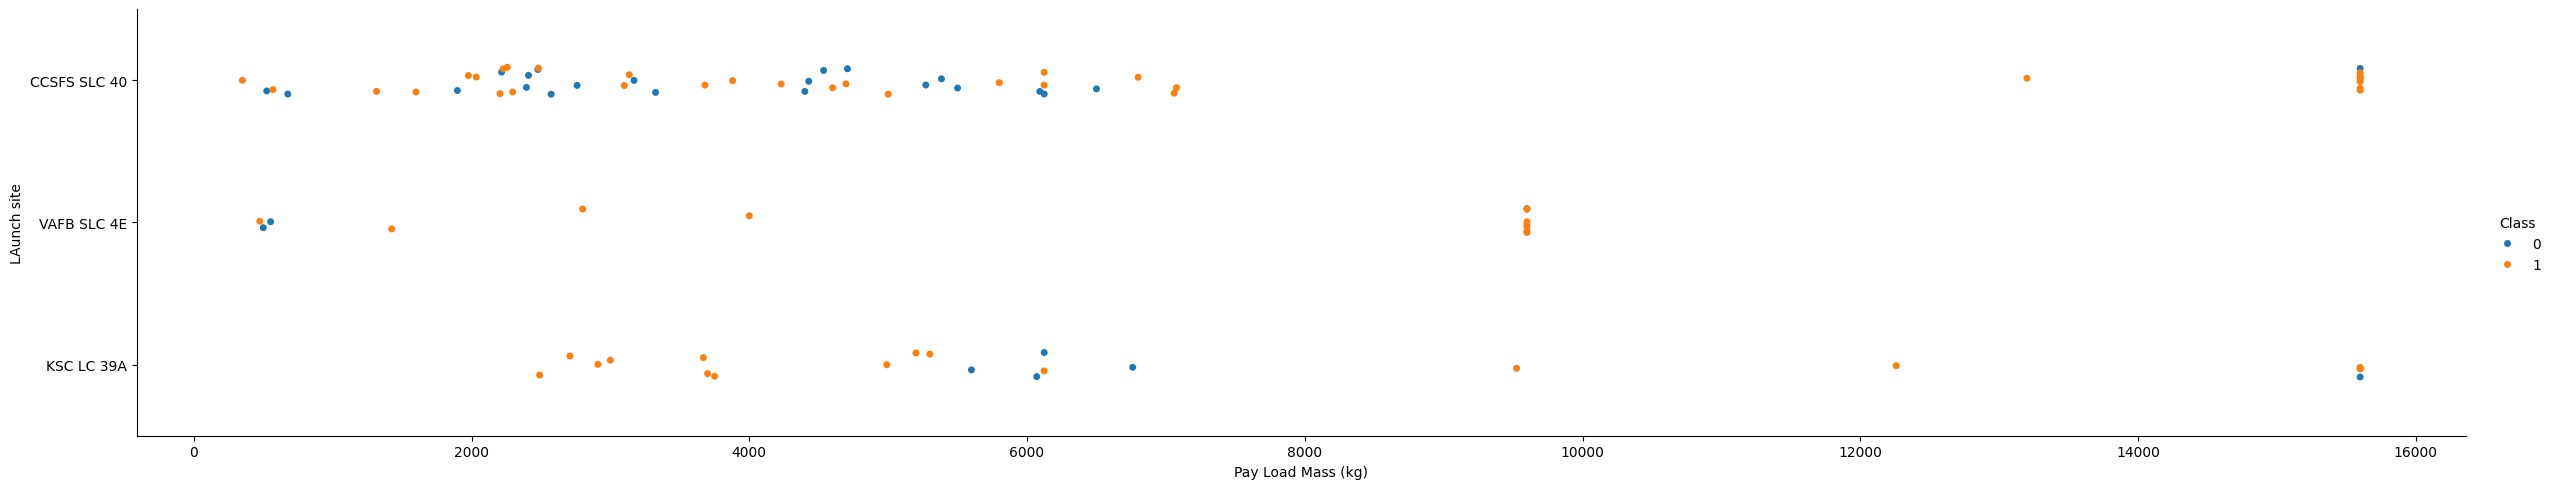

In [7]:
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=5)
plt.xlabel("Pay Load Mass (kg)")
plt.ylabel("LAunch site")
plt.show()

Esta visualización sirve para entender cómo varía la masa de la carga útil según el sitio de lanzamiento y qué implicaciones tiene eso en los resultados.
En este caso el sitio VAFB SLC 4E ha realizado lanzamientos con un maximo de carga cercano a 10,000 kg, mientras que los otros dos sitios con cargas cercanas a 16,000 kg, los tres con casos exitosos.


**Gráfica 4. Visualización de la relación entre la tasa de éxito de cada tipo de órbita.**


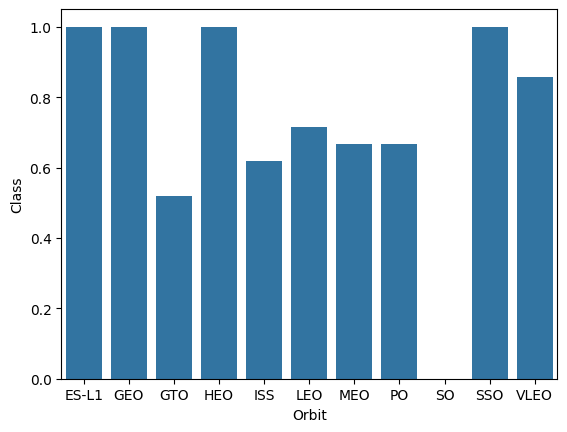

In [8]:
df_1=df.groupby("Orbit")["Class"].mean().reset_index()
sns.barplot(x="Orbit", y="Class", data=df_1)
plt.xlabel("Orbit")
plt.ylabel("Class")
plt.show()

Esa visualización sirve para ver qué tipos de órbita tienen más o menos probabilidad de éxito en los aterrizajes.
Las orbitas con 100% de tasa de exito son ES-L1, GEO, HEO, SSO, mientras que SO tiene una tasa de exito del 0%

**Gráfica 5. Visualización de la relación entre el número de vuelo y el tipo de órbita.**

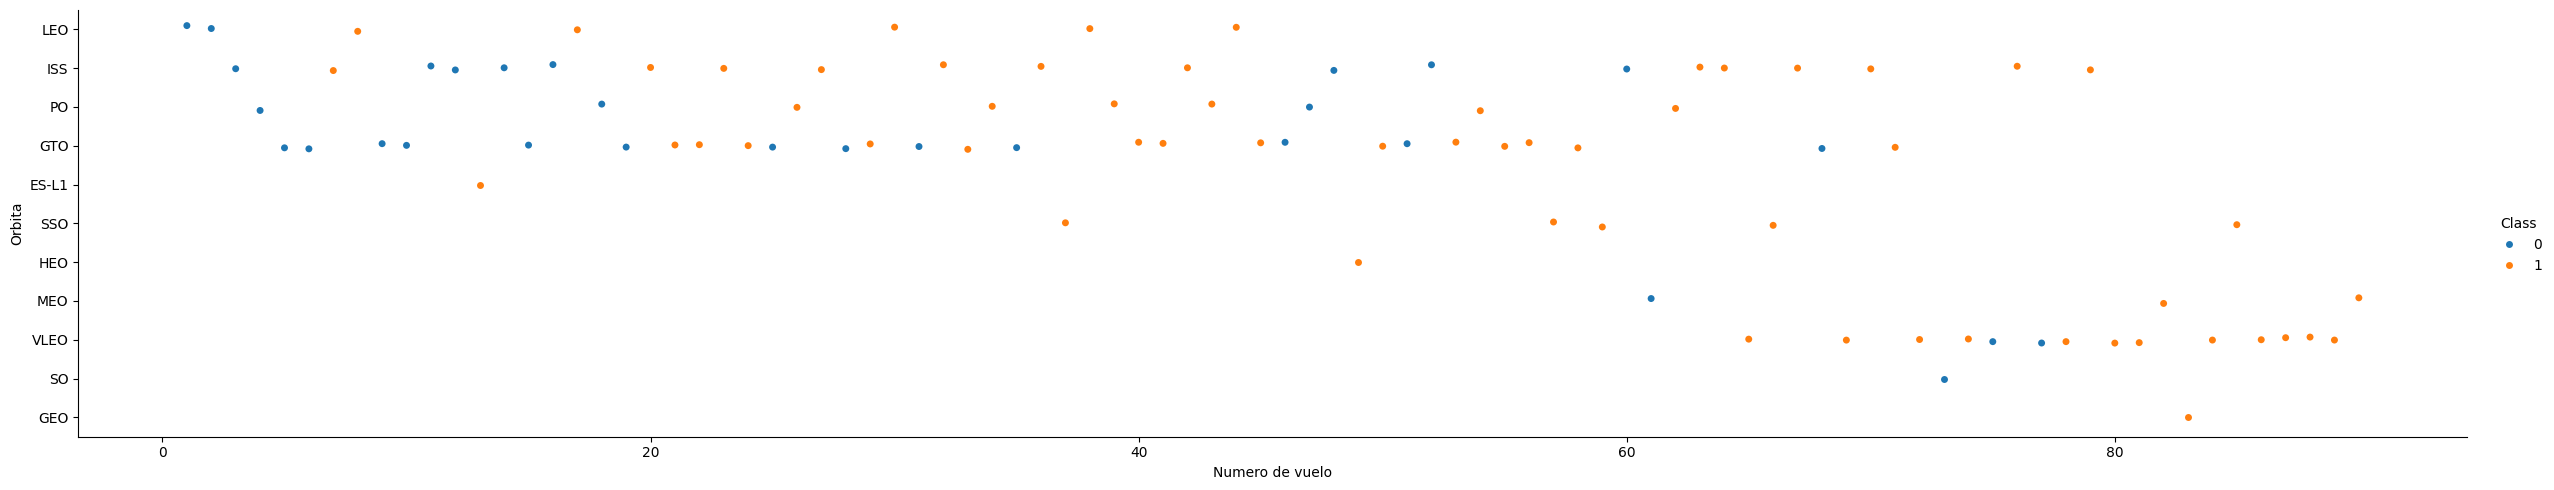

In [9]:
sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect=5)
plt.xlabel("Numero de vuelo")
plt.ylabel("Orbita")
plt.show()

Esta visualización sirve para entender cómo cambia el tipo de órbita usada a lo largo del tiempo (FlightNumber) y cómo eso se relaciona con el éxito de las misiones.
Como se puede ver los primeros intentos se realizaron en orbitas LEO, ISS, PO, GTO, de los cuales los primeros 6 fueron intentos fallidos de aterrizaje, sine mbargo, con el paso de numero de lanzamientos se dejaron de ahcer en estas orbitas y se fueron explorando otras orbitas en las cuales se obtuvieron mas casos exitosos.

**Gráfica 6. Visualización entre la relación de la masa y el tipo de orbita**

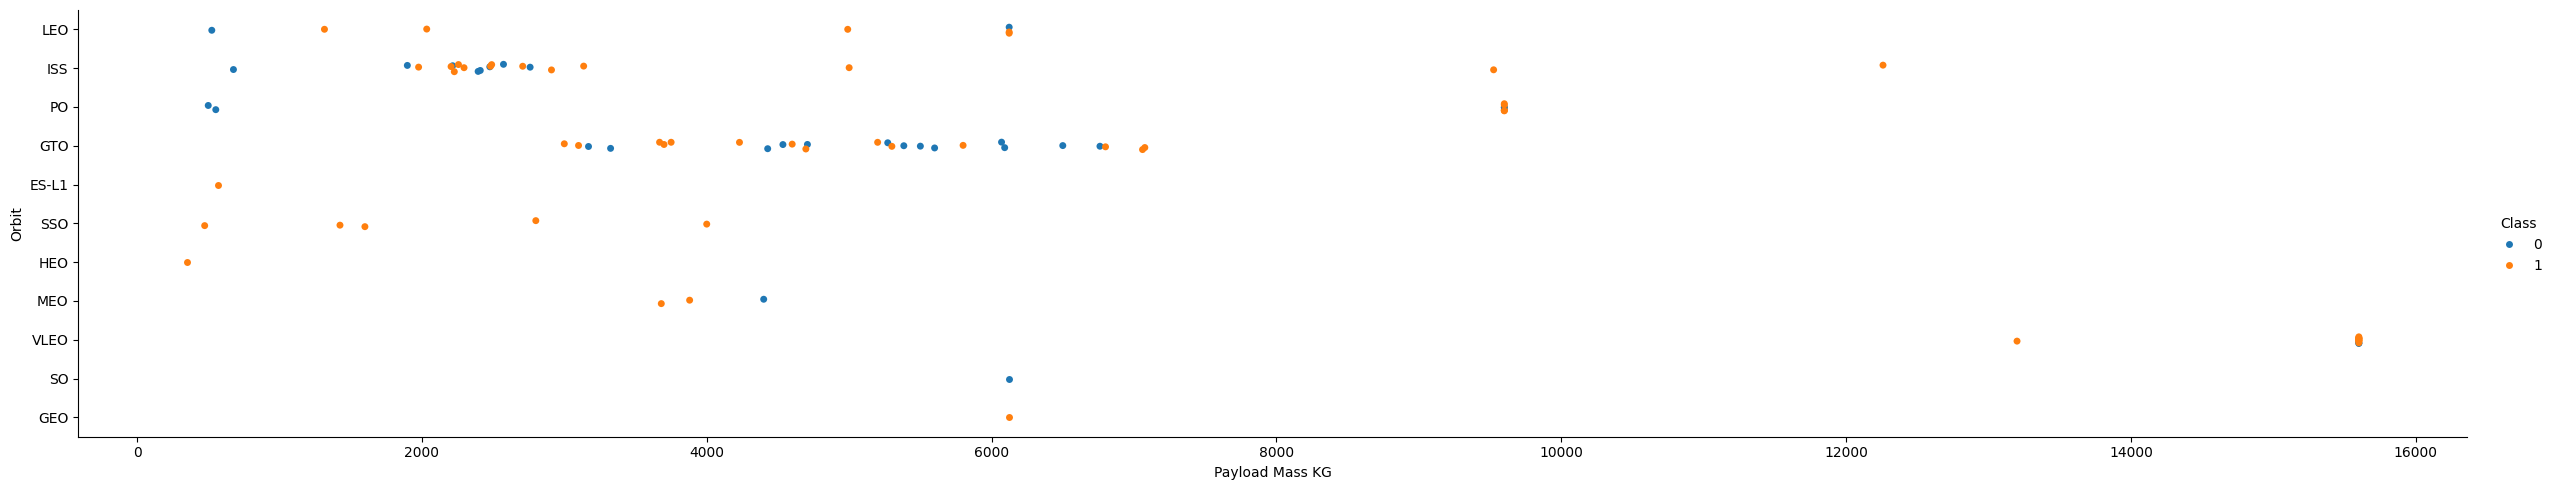

In [10]:
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass KG")
plt.ylabel("Orbit")
plt.show()

Esta visualización sirve para entender cómo se distribuye la masa de la carga útil según el tipo de órbita y si eso influye en el éxito del lanzamiento.
Como se puede observar en la orbita VLEO es en la que se han obtenido aterrizajes exitosos con mayor carga

**Gráfica 7. Visualización de la tendencia anual del éxito de los lanzamientos**

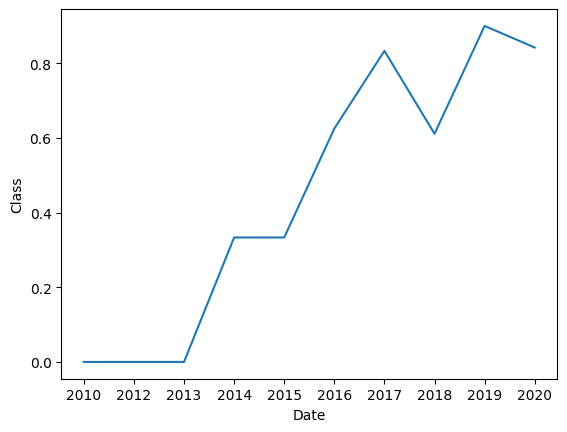

In [11]:
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df_2=df.groupby("Date")["Class"].mean().reset_index()
sns.lineplot(x="Date", y="Class", data=df_2)
plt.xlabel("Date")
plt.ylabel("Class")
plt.show()

Esa visualización sirve para ver cómo ha cambiado el éxito de los lanzamientos a lo largo del tiempo.


### **Preparación de datos para machine learning**



-Selección de variables importantes (features)

-Convertir variables categóricas en números

-Aseguras que todo sea numérico

In [12]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6123.547647,LEO,CCSFS SLC 40,1,False,False,False,without landing pad,1.0,0,B0003
1,2,525.000000,LEO,CCSFS SLC 40,1,False,False,False,without landing pad,1.0,0,B0005
2,3,677.000000,ISS,CCSFS SLC 40,1,False,False,False,without landing pad,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,without landing pad,1.0,0,B1003
4,5,3170.000000,GTO,CCSFS SLC 40,1,False,False,False,without landing pad,1.0,0,B1004


In [13]:
features_one_hot = pd.get_dummies(
    features,
    columns=["Orbit", "LaunchSite", "LandingPad", "Serial"]
)

features_one_hot.head()
features_one_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 81 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   FlightNumber                         90 non-null     int64  
 1   PayloadMass                          90 non-null     float64
 2   Flights                              90 non-null     int64  
 3   GridFins                             90 non-null     bool   
 4   Reused                               90 non-null     bool   
 5   Legs                                 90 non-null     bool   
 6   Block                                90 non-null     float64
 7   ReusedCount                          90 non-null     int64  
 8   Orbit_ES-L1                          90 non-null     bool   
 9   Orbit_GEO                            90 non-null     bool   
 10  Orbit_GTO                            90 non-null     bool   
 11  Orbit_HEO                         

Se puede observar que ya no hay ni un solo valor nulo y tampoco hay datos categoricos

In [14]:
features_one_hot.astype("float64")

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.547647,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15600.000000,2.0,1.0,1.0,1.0,5.0,12.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
86,87.0,15600.000000,3.0,1.0,1.0,1.0,5.0,13.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
87,88.0,15600.000000,6.0,1.0,1.0,1.0,5.0,12.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
88,89.0,15600.000000,3.0,1.0,1.0,1.0,5.0,12.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
features_one_hot.to_csv("/content/drive/MyDrive/dataset_machine_learning.csv", index=False)